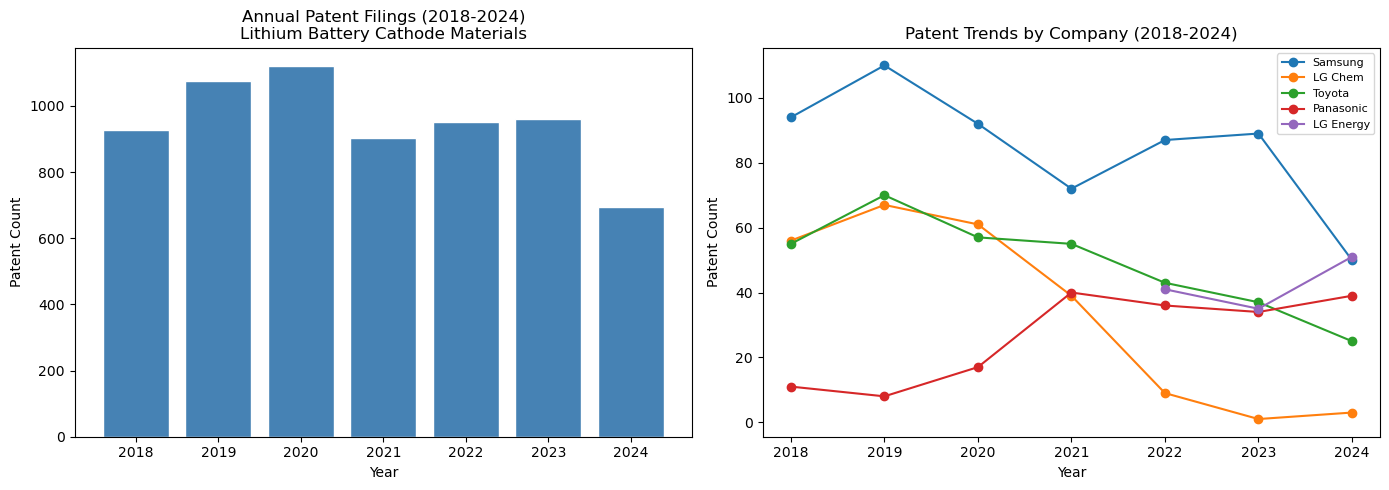

图已保存为 patent_trends.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 读取数据
df_company_year = pd.read_csv('Result_6.csv')
df_yearly = pd.read_csv('Result_7_2.csv')
df_top_companies = pd.read_csv('Result_7_4.csv')

# 简化公司名
name_map = {
    'SAMSUNG ELECTRONICS CO., LTD.': 'Samsung',
    'TOYOTA JIDOSHA KABUSHIKI KAISHA': 'Toyota',
    'LG CHEM, LTD.': 'LG Chem',
    'PANASONIC INTELLECTUAL PROPERTY MANAGEMENT CO., LTD.': 'Panasonic',
    'LG ENERGY SOLUTION, LTD.': 'LG Energy'
}
df_company_year['company'] = df_company_year['company'].map(name_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：每年总专利趋势
axes[0].bar(df_yearly['year'], df_yearly['patent_count'], color='steelblue', edgecolor='white')
axes[0].set_title('Annual Patent Filings (2018-2024)\nLithium Battery Cathode Materials')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Patent Count')

# 图2：各公司逐年趋势
for company in df_company_year['company'].dropna().unique():
    data = df_company_year[df_company_year['company'] == company]
    axes[1].plot(data['year'], data['patent_count'], marker='o', label=company)
axes[1].set_title('Patent Trends by Company (2018-2024)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Patent Count')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('patent_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("图已保存为 patent_trends.png")

In [2]:
import sqlite3
import pandas as pd
import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

# 读取数据
conn = sqlite3.connect('patents.db')
df = pd.read_sql("""
    SELECT p.patent_id, p.patent_title, p.patent_date, a.patent_abstract
    FROM patents p
    JOIN abstracts a ON p.patent_id = a.patent_id
    WHERE a.patent_abstract IS NOT NULL
""", conn)

print(f"共 {len(df)} 条专利")

# 文本清洗
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_abstract'] = df['patent_abstract'].apply(clean_text)
print("清洗完成，示例：")
print(df['clean_abstract'].iloc[0][:200])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yuming/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /Users/yuming/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


共 6619 条专利
清洗完成，示例：
magnetic field generator arranged behind target generating magnetic field front surface target based magnetic force lines include ring shaped outer magnetic body pole axis parallel direction direction


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# TF-IDF 向量化
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_abstract'])
print(f"TF-IDF 矩阵: {X.shape}")

# KMeans 聚成5个主题
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# 每个主题的Top关键词
terms = vectorizer.get_feature_names_out()
print("\n=== 5个主题的核心关键词 ===")
for i in range(5):
    top_indices = kmeans.cluster_centers_[i].argsort()[-10:][::-1]
    top_terms = [terms[j] for j in top_indices]
    print(f"\nCluster {i} ({(df['cluster']==i).sum()} 条): {', '.join(top_terms)}")

TF-IDF 矩阵: (6619, 500)

=== 5个主题的核心关键词 ===

Cluster 0 (2844 条): anode, cathode, layer, electrolyte, first, cell, second, electrode, polymer, metal

Cluster 1 (632 条): solid, solid electrolyte, electrolyte, solid state, state, sulfide, lithium, element, ion, electrolyte material

Cluster 2 (983 条): electrolyte, lithium, battery, compound, formula, solvent, salt, additive, group, secondary

Cluster 3 (779 条): electrode, negative, positive, negative electrode, positive electrode, electrode active, material, active, active material, layer

Cluster 4 (1381 条): material, active, active material, lithium, cathode, particles, oxide, anode, composite, cathode active


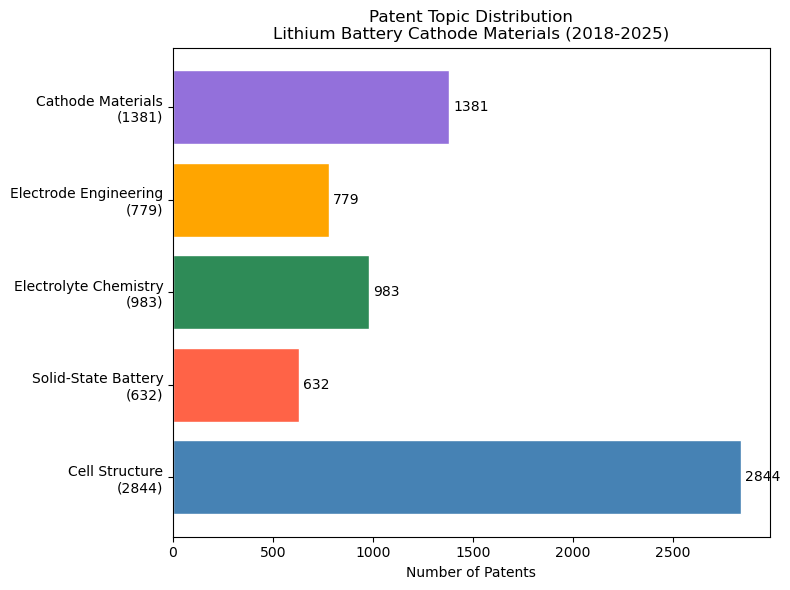

图已保存


In [4]:
import matplotlib.pyplot as plt

cluster_labels = {
    0: 'Cell Structure\n(2844)',
    1: 'Solid-State Battery\n(632)',
    2: 'Electrolyte Chemistry\n(983)',
    3: 'Electrode Engineering\n(779)',
    4: 'Cathode Materials\n(1381)'
}

counts = df['cluster'].value_counts().sort_index()
labels = [cluster_labels[i] for i in counts.index]
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(labels, counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Number of Patents')
ax.set_title('Patent Topic Distribution\nLithium Battery Cathode Materials (2018-2025)')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("图已保存")